In [60]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
PROJECT_PATH = "/content/drive/MyDrive/ML/TP4_ML"

In [62]:
import os
os.chdir(PROJECT_PATH)

print("Directorio actual:", os.getcwd())
print("Archivos:", os.listdir())

Directorio actual: /content/drive/MyDrive/ML/TP4_ML
Archivos: ['TP4_I302_1er_semestre_2026.pdf', 'README.md', 'template_informe.tex', 'Diaco_Abril_Notebook_TP4.ipynb', 'src', 'data', '.git']


In [63]:
import sys

if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

# Trabajo Práctico 4: Aprendizaje No-Supervisado

In [64]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [65]:
import importlib

import src.graphics
import src.utils
import src.data_splitting
import src.preprocessing
import src.pca
import src.models
import src.torch_utils
import src.clustering
import src.tsne

importlib.reload(src.graphics)
importlib.reload(src.clustering)
importlib.reload(src.utils)
importlib.reload(src.data_splitting)
importlib.reload(src.preprocessing)
importlib.reload(src.pca)
importlib.reload(src.models)
importlib.reload(src.torch_utils)
importlib.reload(src.tsne)

<module 'src.tsne' from '/content/drive/MyDrive/ML/TP4_ML/src/tsne.py'>

In [66]:
from src.graphics import (plot_images, plot_class_distribution, plot_images_by_class, plot_mean_image_by_class,
                          plot_cumulative_variance, plot_k_means_inertia_analysis,
                          plot_gmm_log_likelihood_comparison, plot_clustering_k_analysis,
                          plot_tsne_cluster_comparison, plot_cluster_class_heatmap_comparison,
                        plot_cluster_size_comparison, plot_cluster_purity_comparison, plot_images_by_cluster)

from src.utils import (build_class_summary, run_k_means_for_k_range, display_k_means_comparison,
                       run_gmm_for_k_range, display_gmm_comparison, compute_silhouette_for_k_range,
                       build_cluster_size_table, build_cluster_class_table, build_cluster_purity_table)

from src.data_splitting import stratified_train_eval_split, stratified_sample_selection
from src.preprocessing import standardize, inverse_standardize
from src.pca import fit_pca, transform_pca, reconstruct_pca
from src.models import Autoencoder

from src.torch_utils import (train_autoencoder, reconstruct_autoencoder, compute_reconstruction_metrics,
                             encode_autoencoder)

from src.clustering import compute_marginal_gain
from src.tsne import tsne

In [67]:
dataset = pd.read_csv("data/fashion_mnist_subset.csv")

## 1. Inspección de los datos

In [68]:
print(dataset.columns)

Index(['pixel_0', 'pixel_1', 'pixel_2', 'pixel_3', 'pixel_4', 'pixel_5',
       'pixel_6', 'pixel_7', 'pixel_8', 'pixel_9',
       ...
       'pixel_775', 'pixel_776', 'pixel_777', 'pixel_778', 'pixel_779',
       'pixel_780', 'pixel_781', 'pixel_782', 'pixel_783', 'label'],
      dtype='object', length=785)


In [69]:
# Separacion entre pixeles y etiquetas
y = dataset["label"]
X = dataset.drop(columns = ["label"])

In [70]:
print("Shape del dataset completo:", dataset.shape)
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases presentes:", np.unique(y))
print("Rango de pixeles:", X.values.min(), "a", X.values.max())

Shape del dataset completo: (25000, 785)
Shape de X: (25000, 784)
Shape de y: (25000,)
Clases presentes: [0 1 2 3 4 5 6 7 8 9]
Rango de pixeles: 0.0 a 1.0


El conjunto de datos utilizado corresponde a un subconjunto de Fashion-MNIST, una base de imágenes de prendas de vestir y accesorios. Cada observación representa una imagen en escala de grises de $28 \times 28$ píxeles, almacenada como un vector de 784 variables, donde cada variable indica la intensidad de un píxel. Los valores de los píxeles se encuentran normalizados en el rango $[0,1]$, donde valores cercanos a 0 representan píxeles oscuros y valores cercanos a 1 representan píxeles claros.

Además, cada imagen cuenta con una etiqueta numérica que indica su clase real: 0 corresponde a remera/top, 1 a pantalón, 2 a pulóver, 3 a vestido, 4 a abrigo, 5 a sandalia, 6 a camisa, 7 a zapatilla, 8 a bolso y 9 a bota. Dado que el objetivo del trabajo es aplicar técnicas de aprendizaje no supervisado, estas etiquetas no se utilizan para entrenar los modelos, sino únicamente como referencia externa para interpretar y evaluar los resultados obtenidos.

### a) Visualización de imágenes

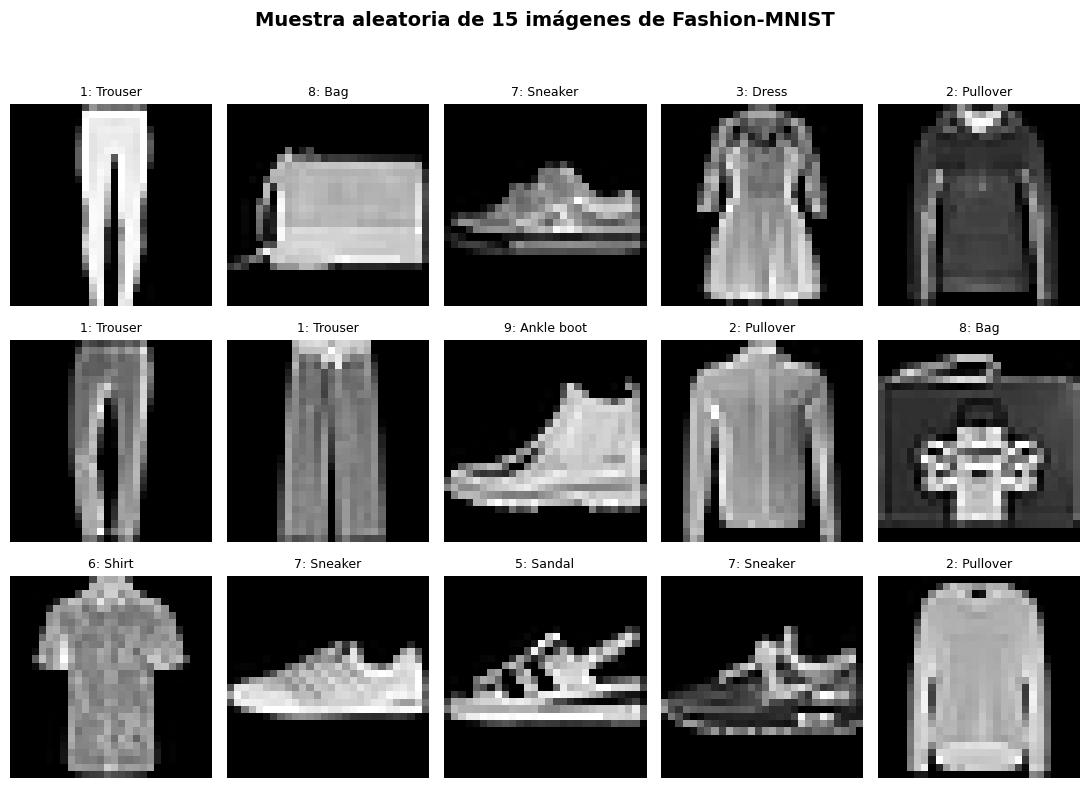

In [71]:
plot_images(X, y, n_images = 15, title = "Muestra aleatoria de 15 imágenes de Fashion-MNIST")

### b) Análisis Exploratorio de Datos

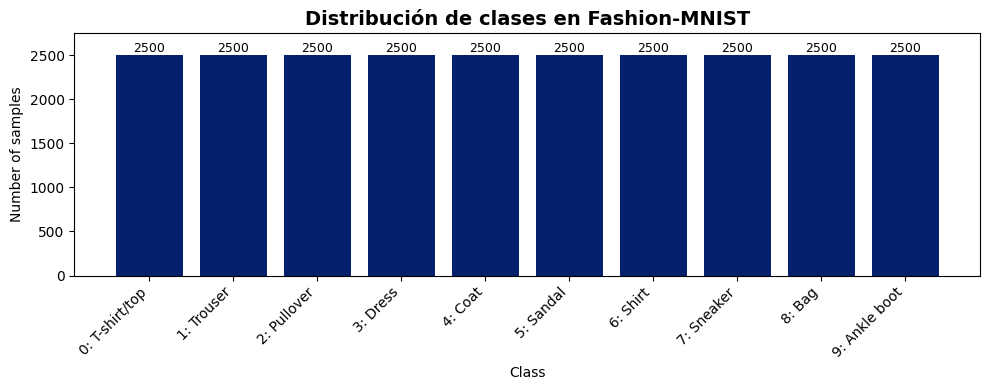

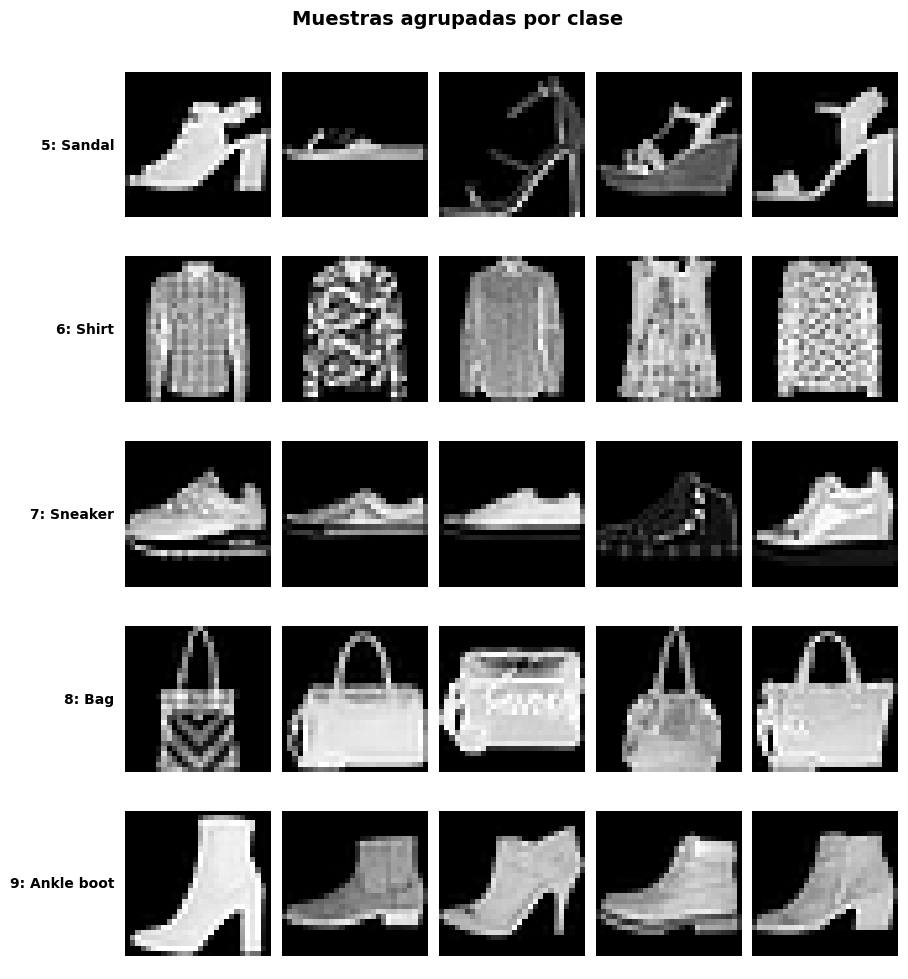

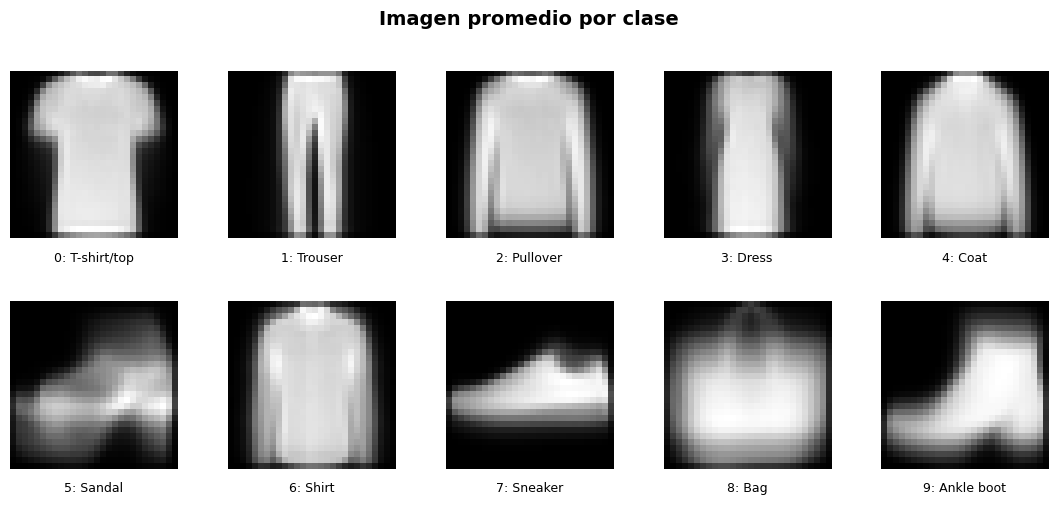

,class_name,count,percentage,mean_intensity,std_intensity,mean_nonzero_pixels
0,T-shirt/top,2500,10.0,0.3284,0.3515,465.99
1,Trouser,2500,10.0,0.2232,0.3437,274.03
2,Pullover,2500,10.0,0.3726,0.3566,507.36
3,Dress,2500,10.0,0.2576,0.3537,335.21
4,Coat,2500,10.0,0.3880,0.3772,472.64
5,Sandal,2500,10.0,0.1378,0.2643,252.65
6,Shirt,2500,10.0,0.3335,0.3409,493.09
7,Sneaker,2500,10.0,0.1684,0.2959,264.23
8,Bag,2500,10.0,0.3557,0.3654,461.16
9,Ankle boot,2500,10.0,0.3008,0.3708,379.03


In [72]:
class_counts = plot_class_distribution(y, title = "Distribución de clases en Fashion-MNIST")
plot_images_by_class(X, y, classes = [5, 6, 7, 8, 9], n_per_class = 5, title = "Muestras agrupadas por clase")
plot_mean_image_by_class(X, y)
build_class_summary(X, y)

In [73]:
print("=== Estadísticas del dataset ===")
print("Cantidad de pixeles por imagen:", X.shape[1])
print("Cantidad de clases:", y.nunique())
print("Diferencia entre clase mayoritaria y minoritaria:", class_counts.max() - class_counts.min())
print("Proporcion minima:", round(class_counts.min() / len(y), 4))
print("Proporcion maxima:", round(class_counts.max() / len(y), 4))
print("Valores faltantes en X:", X.isna().sum().sum())
print("Valores faltantes en y:", y.isna().sum())
print("Promedio global de intensidad:", round(X.to_numpy().mean(), 4))
print("Desvio global de intensidad:", round(X.to_numpy().std(), 4))
print("Porcentaje de pixeles en cero:", round((X.eq(0).sum().sum() / X.size) * 100, 2), "%")

=== Estadísticas del dataset ===
Cantidad de pixeles por imagen: 784
Cantidad de clases: 10
Diferencia entre clase mayoritaria y minoritaria: 0
Proporcion minima: 0.1
Proporcion maxima: 0.1
Valores faltantes en X: 0
Valores faltantes en y: 0
Promedio global de intensidad: 0.2866
Desvio global de intensidad: 0.3533
Porcentaje de pixeles en cero: 50.19 %


A partir de los gráficos y la tabla, se observa que el dataset está perfectamente balanceado: cada una de las 10 clases tiene 2500 imágenes, es decir, representa el 10% del total. Esto es importante porque ninguna clase queda sobrerrepresentada, por lo que los métodos de agrupamiento no deberían verse influenciados por diferencias en la cantidad de ejemplos.

Al mirar las muestras agrupadas por clase, aparece bastante variabilidad dentro de una misma etiqueta. Esto se nota especialmente en sandalias, zapatillas, botas y bolsos, donde cambian las formas, orientaciones y estilos. Por este motivo, no sería raro que algunos métodos no supervisados tengan dificultades para separar las observaciones exactamente según las etiquetas originales.

Las imágenes promedio permiten ver la forma típica de cada categoría. Algunas clases, como pantalón, zapatilla, bolso y bota, tienen siluetas bastante distinguibles. En cambio, prendas como remera/top, pulóver, abrigo y camisa son visualmente más parecidas entre sí, lo que podría hacer más difícil diferenciarlas.

Por último, la tabla muestra que las clases ocupan distintas proporciones de la imagen. Sandalias y zapatillas tienen menos píxeles blancos y una intensidad promedio más baja, mientras que pulóveres, abrigos y camisas ocupan una mayor área visual.

### c) Separando los datos

In [74]:
(xtr, ytr), (xeval, yeval) = stratified_train_eval_split(X, y, eval_size = 0.20)

In [75]:
print("X_train:", xtr.shape)
print("y_train:", ytr.shape)
print("X_eval:", xeval.shape)
print("y_eval:", yeval.shape)

X_train: (20000, 784)
y_train: (20000,)
X_eval: (5000, 784)
y_eval: (5000,)


## 2. Reducción de Dimensionalidad

### a) Estandarizando y aplicando PCA

PCA, o Análisis de Componentes Principales, es una técnica de reducción de dimensionalidad. La idea principal es transformar los datos originales en un nuevo conjunto de variables, llamadas componentes principales, que resumen la mayor parte de la información posible.

En este caso, cada imagen tiene 784 variables, una por cada píxel. Muchas de estas variables pueden estar relacionadas entre sí o aportar información parecida. PCA busca nuevas direcciones en los datos donde haya mayor variabilidad, y ordena esas direcciones desde la más importante hasta la menos importante.

De esta forma, en lugar de trabajar con los 784 píxeles originales, podemos quedarnos con una cantidad menor de componentes principales que expliquen gran parte de la variabilidad del dataset. Esto permite simplificar los datos, reducir el costo computacional y, al mismo tiempo, conservar la estructura más importante de las imágenes.

In [76]:
# Standardize
xtr_std, xtr_mean, xtr_std_val = standardize(xtr)
xeval_std = standardize(xeval, train = False, xtr_mean = xtr_mean, xtr_std = xtr_std_val)

In [ ]:
# Applying PCA
ztr_pca, pca_params = fit_pca(xtr_std, variance_threshold = 0.95) # Using default variance threshold
zeval_pca = transform_pca(xeval_std, pca_params)

In [ ]:
print("=== Resultados de PCA ===")
print("Dimensiones originales de entrenamiento:", xtr.shape)
print("Dimensiones con PCA de entrenamiento:", ztr_pca.shape)
print()
print("Dimensiones originales de evaluación:", xeval.shape)
print("Dimensiones con PCA de evaluación:", zeval_pca.shape)
print()
print("Cantidad de componentes seleccionadas:", pca_params["m_components"])
print("Varianza explicada acumulada:", round(pca_params["cumulative_variance_ratio"][pca_params["m_components"] - 1], 4))

=== Resultados de PCA ===
Dimensiones originales de entrenamiento: (20000, 784)
Dimensiones con PCA de entrenamiento: (20000, 252)

Dimensiones originales de evaluación: (5000, 784)
Dimensiones con PCA de evaluación: (5000, 252)

Cantidad de componentes seleccionadas: 252
Varianza explicada acumulada: 0.9502


### b) Varianza explicada acumulada vs componentes (90% de varianza explicada)

In [ ]:
ztr_pca_90, pca_params_90 = fit_pca(xtr_std, variance_threshold = 0.90)
zeval_pca_90 = transform_pca(xeval_std, pca_params_90)

In [80]:

xeval_reconstructed_std = reconstruct_pca(xeval_pca_90, pca_params_90)
xeval_reconstructed_pca = inverse_standardize(xeval_reconstructed_std, xtr_mean, xtr_std_val)

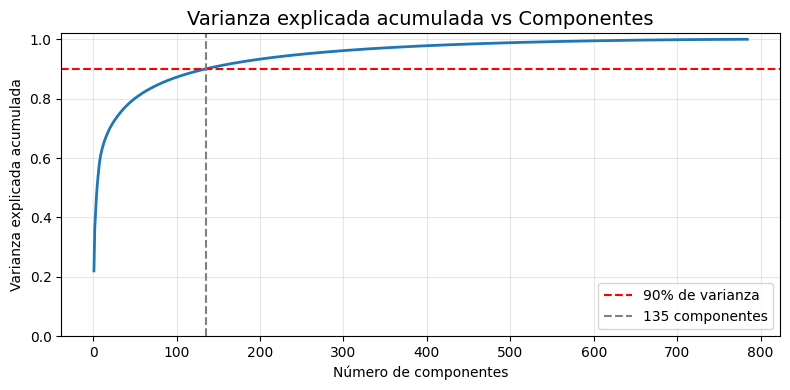

=== Resultados de PCA (90%) ===
Dimensiones originales de entrenamiento: (20000, 784)
Dimensiones con PCA de entrenamiento: (20000, 135)

Dimensiones originales de evaluación: (5000, 784)
Dimensiones con PCA de evaluación: (5000, 135)

Cantidad de componentes seleccionadas: 135
Varianza explicada acumulada: 0.9004


In [ ]:
plot_cumulative_variance(pca_params_90, variance_threshold = 0.90)
print("=== Resultados de PCA (90%) ===")
print("Dimensiones originales de entrenamiento:", xtr.shape)
print("Dimensiones con PCA de entrenamiento:", ztr_pca_90.shape)
print()
print("Dimensiones originales de evaluación:", xeval.shape)
print("Dimensiones con PCA de evaluación:", zeval_pca_90.shape)
print()
print("Cantidad de componentes seleccionadas:", pca_params_90["m_components"])
print("Varianza explicada acumulada:", round(pca_params_90["cumulative_variance_ratio"][pca_params_90["m_components"] - 1], 4))

### Imagen original vs imagen reconstruida

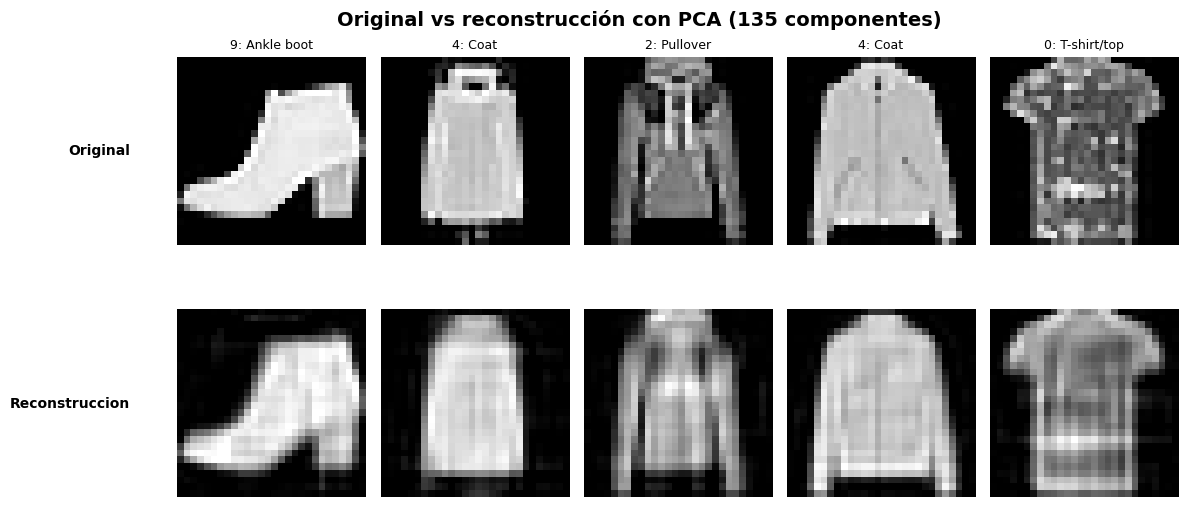

=== Error de reconstrucción ===
MSE: 0.008091
RMSE: 0.089949
MAE: 0.054488
Error minimo por imagen: 0.001379
Error promedio por imagen: 0.008091
Error maximo por imagen: 0.0812


In [ ]:
comp = pca_params_90["m_components"]
plot_images(xeval, yeval, n_images = 5, compare_with = xeval_reconstructed_pca, n_cols = 5, title = f"Original vs reconstrucción con PCA ({comp} componentes)")

# Reconstruction metrics
xeval_values = xeval.to_numpy() if hasattr(xeval, "to_numpy") else np.asarray(xeval)
xeval_reconstructed_pca_values = xeval_reconstructed_pca.to_numpy() if hasattr(xeval_reconstructed_pca, "to_numpy") else np.asarray(xeval_reconstructed_pca)

reconstruction_mse = np.mean((xeval_values - xeval_reconstructed_pca_values) ** 2)
reconstruction_rmse = np.sqrt(reconstruction_mse)
mean_absolute_error = np.mean(np.abs(xeval_values - xeval_reconstructed_pca_values))

print("=== Error de reconstrucción ===")
print("MSE:", round(reconstruction_mse, 6))
print("RMSE:", round(reconstruction_rmse, 6))
print("MAE:", round(mean_absolute_error, 6))

reconstruction_error_per_image = np.mean((xeval_values - xeval_reconstructed_pca_values) ** 2, axis=1)

print("Error minimo por imagen:", round(reconstruction_error_per_image.min(), 6))
print("Error promedio por imagen:", round(reconstruction_error_per_image.mean(), 6))
print("Error maximo por imagen:", round(reconstruction_error_per_image.max(), 6))

Al comparar las imágenes originales con las reconstruidas, se nota que las segundas pierden nitidez y se ven más borrosas. Esto es esperable, porque pasamos de representar cada imagen con 784 píxeles a usar solo 135 componentes principales.

Aun así, la forma general de las prendas se mantiene bastante bien. En la mayoría de los casos todavía se puede reconocer qué tipo de objeto es, aunque se pierdan detalles como texturas, bordes o contrastes.

Los errores de reconstrucción también acompañan esta idea: el MSE fue 0.0081, el RMSE 0.0899 y el MAE 0.0545. Como los píxeles están en el rango $[0,1]$, estos valores son relativamente bajos. Entonces, con el 90% de la varianza, PCA logra reducir mucho la cantidad de variables sin perder la información visual más importante.

### c) Modelo Autoencoder Deterministico (AE)

In [83]:
# Define latent dimension
latent_dim = pca_params_90["m_components"]

In [ ]:
# Convert data into tensors
xtr_tensor = torch.tensor(xtr.to_numpy(), dtype = torch.float32)
xeval_tensor = torch.tensor(xeval.to_numpy(), dtype = torch.float32) 

In [85]:
# Build Datasets
train_dataset = TensorDataset(xtr_tensor, xtr_tensor)
eval_dataset = TensorDataset(xeval_tensor, xeval_tensor)

train_loader = DataLoader(train_dataset, batch_size = 128, shuffle = True)
eval_loader = DataLoader(eval_dataset, batch_size = 128, shuffle = False)

In [86]:
# Set seed and device
seed = 42

np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [87]:
# Define autoencoder
autoencoder = Autoencoder(input_size = 784, latent_dim = latent_dim, hidden_nodes = [512, 256],
                          activation = "relu")

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr = 0.001)

El autoencoder se entrenó minimizando el error de reconstrucción mediante `MSELoss`. Esta pérdida corresponde al promedio de los errores cuadrados entre la imagen original y su reconstrucción. Es equivalente, salvo por una constante de escala, a minimizar la suma de las normas al cuadrado $\sum_i \|x_i - \hat{x}_i\|^2$ por lo que mantiene el mismo objetivo de optimización.

In [88]:
print("Dimensión latente:", latent_dim)

Dimensión latente: 135


In [ ]:
# Train autoencoder
history_ae = train_autoencoder(autoencoder, train_loader, eval_loader, loss_fn, optimizer,
                               epochs = 30, device = device, verbose = True)

In [90]:
# Reconstruct and evaluate metrics
xeval_reconstructed_ae = reconstruct_autoencoder(autoencoder, xeval, device)
ae_metrics = compute_reconstruction_metrics(xeval, xeval_reconstructed_ae)

In [91]:
print("=== Error de reconstrucción AE ===")
print("MSE:", round(ae_metrics["mse"], 6))
print("RMSE:", round(ae_metrics["rmse"], 6))
print("MAE:", round(ae_metrics["mae"], 6))

xeval_values = xeval.to_numpy() if hasattr(xeval, "to_numpy") else np.asarray(xeval)
xeval_reconstructed_values = xeval_reconstructed_ae.to_numpy() if hasattr(xeval_reconstructed_ae, "to_numpy") else np.asarray(xeval_reconstructed_ae)

reconstruction_error_per_image = np.mean((xeval_values - xeval_reconstructed_values) ** 2, axis=1)

print("Error minimo por imagen:", round(reconstruction_error_per_image.min(), 6))
print("Error promedio por imagen:", round(reconstruction_error_per_image.mean(), 6))
print("Error maximo por imagen:", round(reconstruction_error_per_image.max(), 6))

=== Error de reconstrucción AE ===
MSE: 0.010324
RMSE: 0.101605
MAE: 0.052044
Error minimo por imagen: 0.001005
Error promedio por imagen: 0.010324
Error maximo por imagen: 0.094528


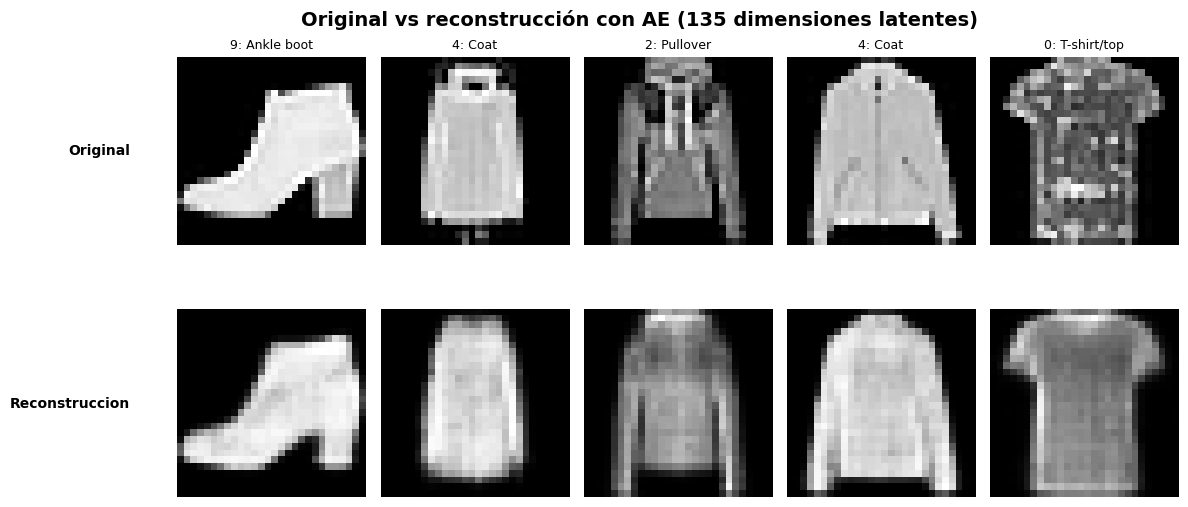

In [92]:
plot_images(xeval, yeval, n_images = 5, compare_with = xeval_reconstructed_ae, n_cols = 5,
            title = f"Original vs reconstrucción con AE ({latent_dim} dimensiones latentes)")

### d) PCA vs AE

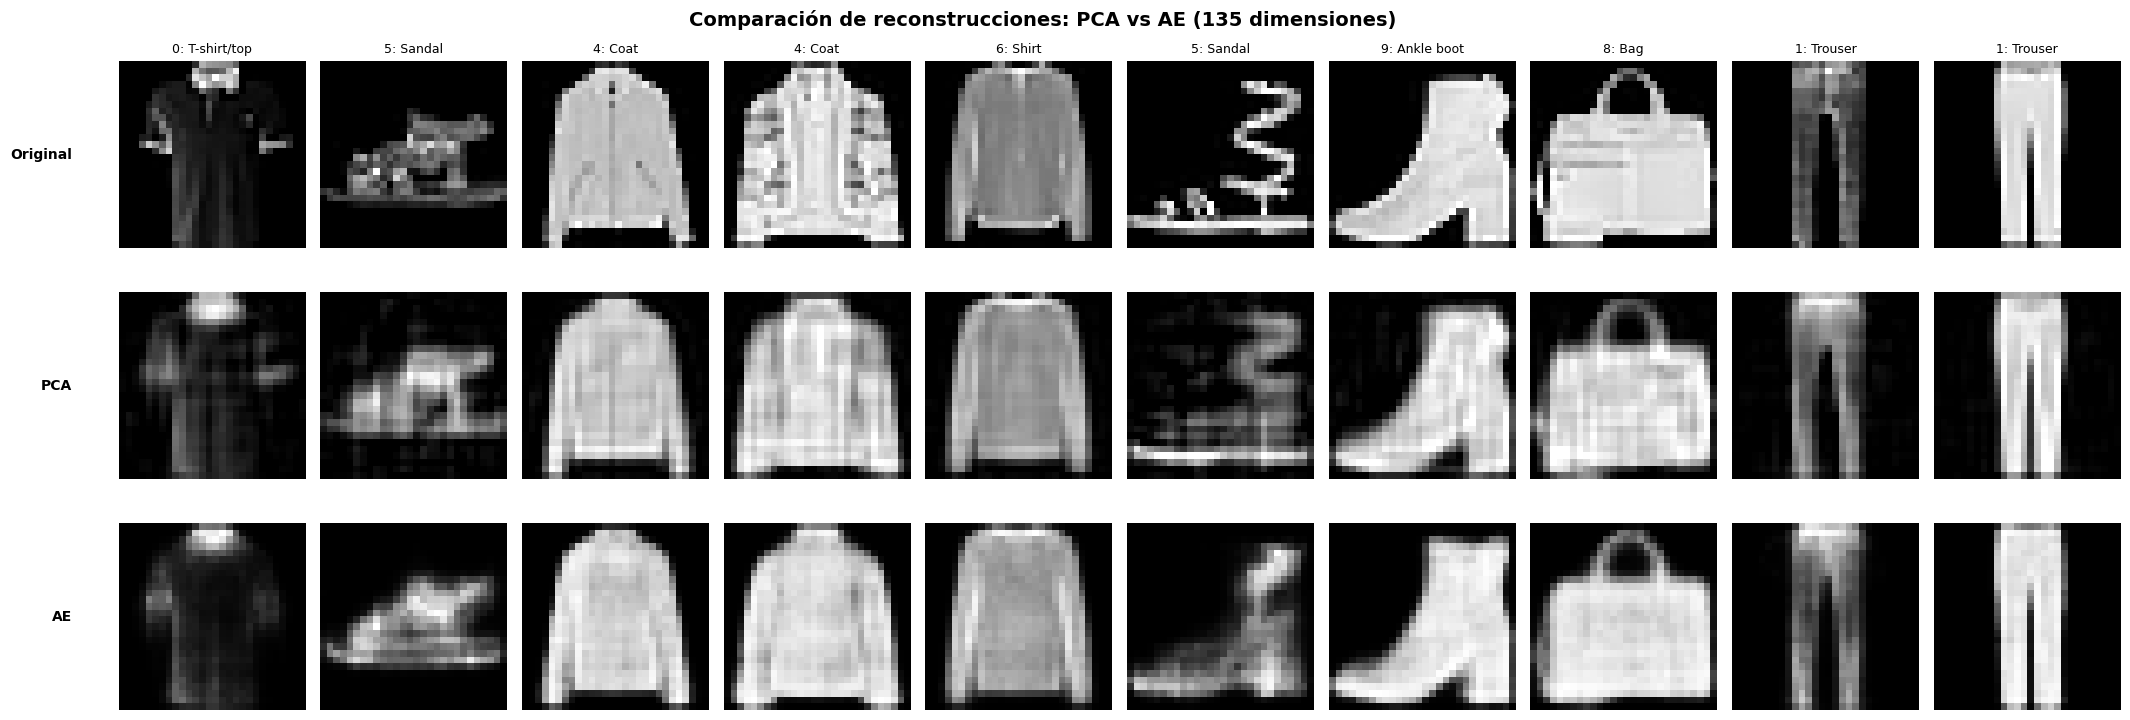

In [93]:
rng = np.random.default_rng(42)
comparison_indices = rng.choice(len(xeval), size = 10, replace = False)

plot_images(xeval, yeval, indices = comparison_indices, compare_with = [xeval_reconstructed_pca, xeval_reconstructed_ae],
            comparison_labels = ("Original", "PCA", "AE"), n_cols = 10, title = f"Comparación de reconstrucciones: PCA vs AE ({latent_dim} dimensiones)")

Comparando las reconstrucciones, se ve que ambos métodos logran conservar la forma general de las prendas. Las imágenes reconstruidas pierden nitidez y detalles, pero en la mayoría de los casos todavía se puede reconocer qué objeto era.

PCA tuvo un MSE de 0.0081 y un RMSE de 0.0899, mientras que el autoencoder tuvo un MSE de 0.0103 y un RMSE de 0.1015. En estas métricas, PCA reconstruyó un poco mejor. Sin embargo, el MAE fue levemente menor en el autoencoder: 0.0522 frente a 0.0545 en PCA. Esto muestra que la diferencia entre los dos métodos no es enorme, pero PCA tuvo una pequeña ventaja en el error cuadrático.

Visualmente, PCA tiende a generar imágenes más borrosas y un poco mas ruuidosas. El autoencoder pierde un poc mas de detalle, pero en ambos casos se mantiene bastante bien la silueta general. Usando la misma dimensión latente de 135, ambos métodos reducen la dimensionalidad y conservan la información principal, aunque en este caso PCA obtuvo una reconstrucción ligeramente mejor según MSE y RMSE.

### e) Transformando los datos en el nuevo espacio latente

In [ ]:
ztr_ae_latent = encode_autoencoder(autoencoder, xtr, device)
zeval_ae_latent = encode_autoencoder(autoencoder, xeval, device)

In [ ]:

print("Latente PCA train:", ztr_pca_90.shape)
print("Latente PCA eval:", zeval_pca_90.shape)
print("Latente AE train:", ztr_ae_latent.shape)
print("Latente AE eval:", zeval_ae_latent.shape)

Latente PCA train: (20000, 135)
Latente PCA eval: (5000, 135)
Latente AE train: (20000, 135)
Latente AE eval: (5000, 135)


## 3. Clustering

In [ ]:
# Stratified sample
n_samples = 3000

zeval_pca_sample, ytr_sample, sample_indices = stratified_sample_selection(zeval_pca_90, ytr, n_samples)
zeval_ae_sample = zeval_ae_latent[sample_indices]

In [ ]:
k_values = range(5, 16)

### a) K-Means

In [ ]:
kmeans_pca_results = run_k_means_for_k_range(zeval_pca_sample, k_values, init = "kmeans++", random_state = 6)

In [ ]:
kmeans_ae_results = run_k_means_for_k_range(zeval_ae_sample, k_values, init = "kmeans++", random_state = 6)

Resultados de k-Means


K,PCA inertia,PCA iterations,AE inertia,AE iterations
5,1323547.034,26,202523.094,10
6,1229775.316,45,192497.562,12
7,1163253.569,84,178970.750,15
8,1128014.731,42,172148.281,30
9,1096143.506,38,168316.000,14
10,1070231.016,33,161156.719,27
11,1034175.466,26,157182.109,27
12,1001394.438,21,154251.000,26
13,978394.087,22,149908.375,31
14,960209.582,26,148124.203,35


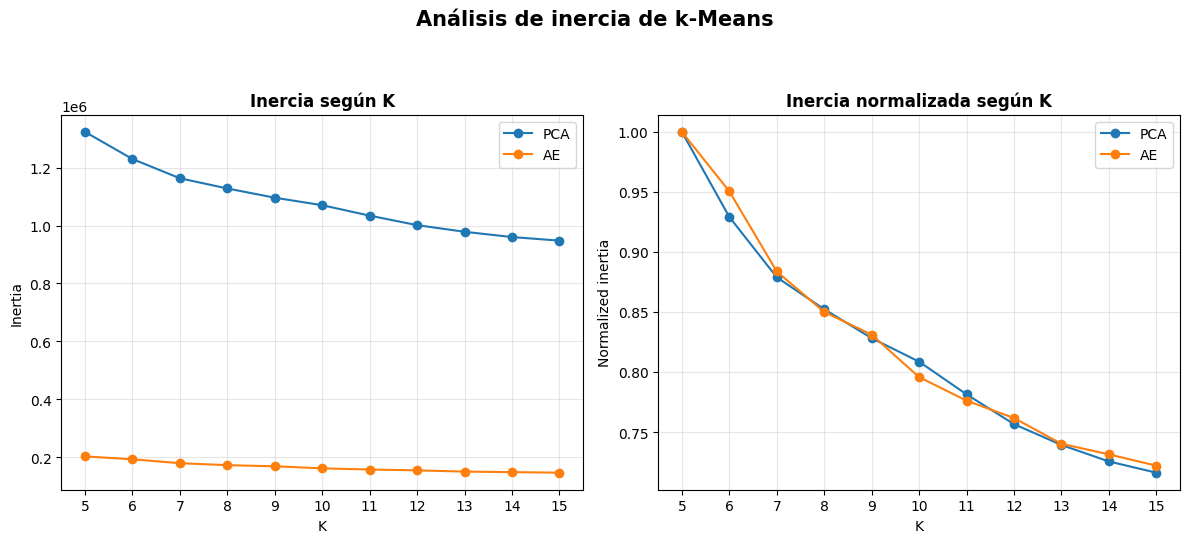

In [102]:
display_k_means_comparison(kmeans_pca_results, kmeans_ae_results)
plot_k_means_inertia_analysis(kmeans_pca_results, kmeans_ae_results)

En k-Means se usa la inercia para medir qué tan compactos son los clusters. Esta métrica suma las distancias cuadradas entre cada punto y el centroide del cluster al que fue asignado. Entonces, cuanto menor es la inercia, más cerca están los puntos de sus centroides.

Al aumentar $K$, la inercia baja, porque el modelo tiene más centroides para repartir los datos. Esto se ve tanto en PCA como en AE. Sin embargo, para comparar ambas curvas se usó la inercia normalizada, porque la inercia depende mucho de la escala de los datos. Aunque PCA y AE tienen la misma cantidad de dimensiones, sus valores latentes no necesariamente están en la misma escala. Por eso, comparar la inercia cruda puede ser engañoso.

Con la normalización, cada curva empieza en 1 y se observa la mejora relativa al aumentar $K$. En ambos casos, la inercia disminuye más al principio y luego la caída se vuelve más suave, lo que sugiere que agregar más clusters empieza a aportar cada vez menos.

### b) GMM

In [ ]:
gmm_pca_results = run_gmm_for_k_range(zeval_pca_sample, k_values, random_state = 6)

In [ ]:
gmm_ae_results = run_gmm_for_k_range(zeval_ae_sample, k_values, random_state = 6)

Resultados de GMM


K,PCA log-likelihood,PCA iterations,AE log-likelihood,AE iterations
5,-613898.203,129,-390763.888,45
6,-613203.328,139,-382514.701,85
7,-609385.937,120,-371024.829,139
8,-606106.697,200,-362246.073,112
9,-603482.190,200,-355260.274,115
10,-605064.657,165,-351941.793,179
11,-603881.319,184,-343769.414,112
12,-601931.713,200,-335365.368,200
13,-597757.553,200,-332638.035,200
14,-595862.805,152,-326693.253,86


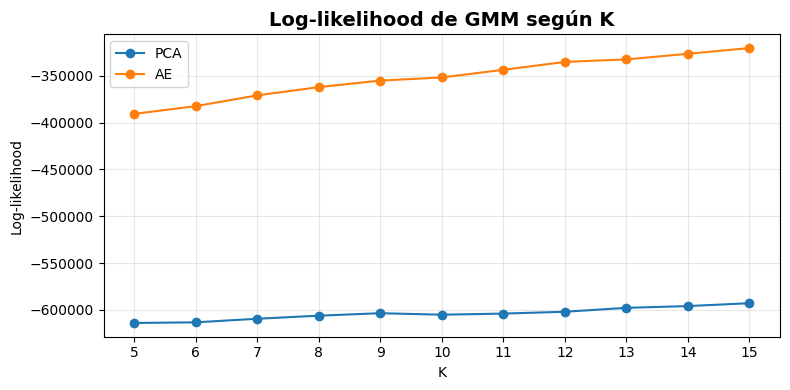

In [105]:
display_gmm_comparison(gmm_pca_results, gmm_ae_results)
plot_gmm_log_likelihood_comparison(gmm_pca_results, gmm_ae_results)

En GMM se usa el log-likelihood para medir qué tan bien el modelo probabilístico explica los datos. Como GMM representa los datos como una mezcla de gaussianas, el log-likelihood indica qué tan probable es observar los puntos bajo las componentes aprendidas. En este caso, valores más altos significan un mejor ajuste.

Al aumentar $K$, el log-likelihood tiende a subir, porque el modelo tiene más componentes gaussianas y puede adaptarse mejor a los datos. Esto se observa tanto en PCA como en AE. Aun así, no alcanza con elegir el mayor $K$, porque más componentes casi siempre mejoran el ajuste.

A diferencia de la inercia, no normalicé el log-likelihood de la misma forma, porque puede tomar valores negativos y su escala depende de la densidad del modelo. Para analizarlo mejor, conviene mirar la ganancia marginal: cuánto mejora el log-likelihood al pasar de un $K$ al siguiente.

### c) Ganancias decrecientes Y Silhouette score

In [106]:
kmeans_pca_gain = compute_marginal_gain(kmeans_pca_results, metric="inertia", mode="decrease")
kmeans_ae_gain = compute_marginal_gain(kmeans_ae_results, metric="inertia", mode="decrease")

In [ ]:
kmeans_pca_silhouette = compute_silhouette_for_k_range(zeval_pca_sample, kmeans_pca_results)
kmeans_ae_silhouette = compute_silhouette_for_k_range(zeval_ae_sample, kmeans_ae_results)

In [108]:
gmm_pca_gain = compute_marginal_gain(gmm_pca_results, metric = "log_likelihood", mode = "increase")
gmm_ae_gain = compute_marginal_gain(gmm_ae_results, metric = "log_likelihood", mode = "increase")

In [ ]:
gmm_pca_silhouette = compute_silhouette_for_k_range(zeval_pca_sample, gmm_pca_results)
gmm_ae_silhouette = compute_silhouette_for_k_range(zeval_ae_sample, gmm_ae_results)

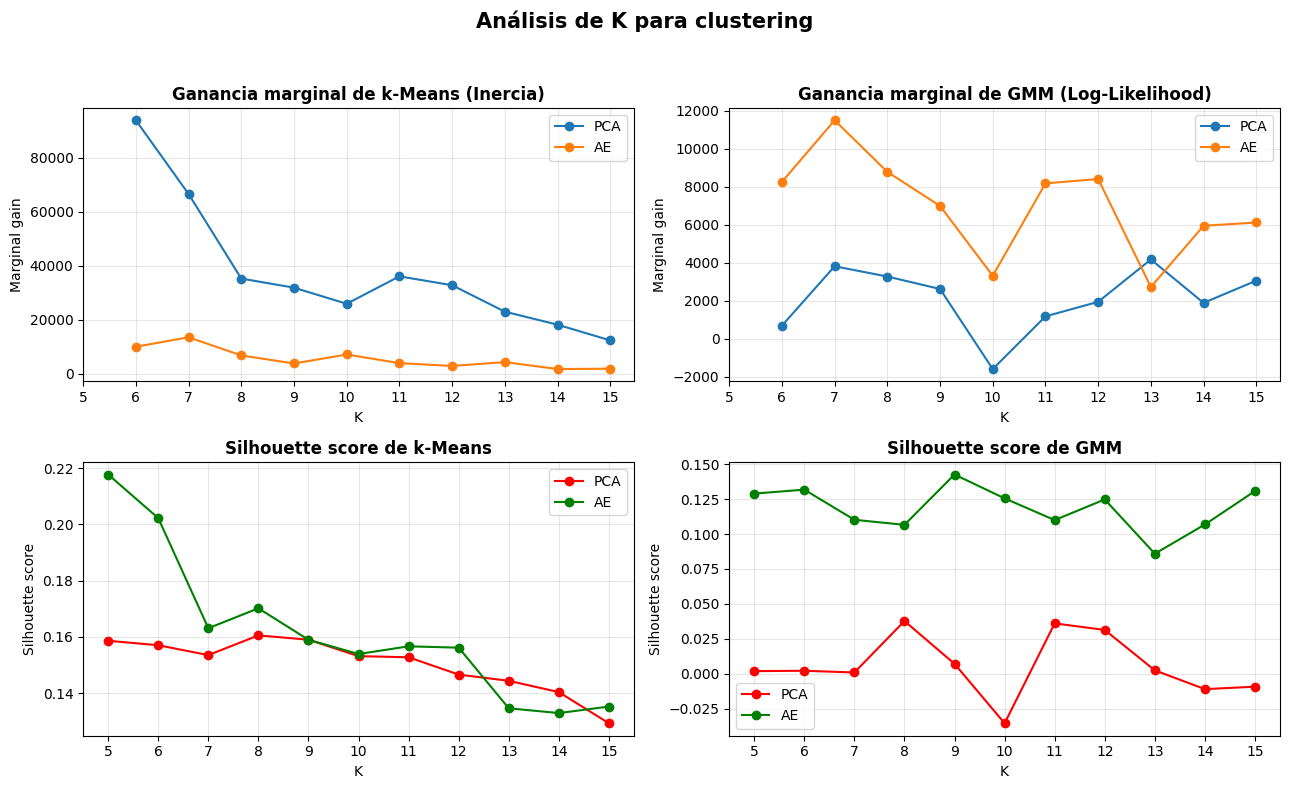

In [110]:
plot_clustering_k_analysis(kmeans_pca_gain, kmeans_ae_gain, gmm_pca_gain, gmm_ae_gain, kmeans_pca_silhouette, kmeans_ae_silhouette, gmm_pca_silhouette, gmm_ae_silhouette)

La ganancia marginal muestra cuánto mejora el modelo al agregar un cluster más, mientras que el Silhouette score ayuda a ver qué tan separados y compactos quedan los grupos. Si bien se calcularon las métricas tanto para PCA como para AE, se le da más peso a PCA porque el siguiente inciso pide continuar trabajando sobre el espacio latente de PCA.

En k-Means, la ganancia marginal es alta para valores bajos de $K$, especialmente al pasar de $K=5$ a $K=6$ y de $K=6$ a $K=7$. Luego empieza a disminuir, lo cual muestra que agregar clusters sigue mejorando la inercia, pero cada vez con menor impacto. De todos modos, en $K=8$ todavía se observa una mejora apreciable respecto de $K=7$, por lo que no parece ser un valor excesivo ni completamente innecesario.

Al mirar el Silhouette score, el mejor valor se obtiene en $K=8$. Entonces, combinando ambos criterios, $K=8$ resulta una elección razonable: por un lado, es el valor con mejor separación promedio entre clusters según Silhouette; por otro lado, la ganancia marginal muestra que hasta ese punto todavía hay una mejora relevante en la compactación de los grupos. Por eso se toma $K=8$ como valor final para k-Means.

En GMM, las ganancias marginales son más irregulares. Hay valores donde el log-likelihood mejora bastante, pero esas mejoras no siempre se traducen en clusters más claros. En PCA, el Silhouette score es bajo en general, aunque sus mejores valores aparecen alrededor de $K=8$ y $K=11$. Por eso, se toma $K=8$ como una opción razonable para GMM: mantiene un desempeño relativamente bueno en PCA y evita elegir un valor más alto solo por una mejora puntual.

En conjunto, los resultados muestran que el mejor $K$ no tiene por qué coincidir exactamente con las 10 clases reales de Fashion-MNIST. Esto tiene sentido porque los métodos no supervisados no usan las etiquetas, sino que agrupan según similitudes en los datos. Algunas prendas visualmente parecidas, como remeras, camisas, pulóveres y abrigos, pueden quedar juntas, mientras que otras clases con más variabilidad pueden dividirse. Por eso, se decide continuar con $K=8$ tanto para k-Means como para GMM.

### d) Calidad de los clusters

In [111]:
# Chosen K
k_kmeans = 8
k_gmm = 8

In [112]:
# Labels
best_labels_kmeans = kmeans_pca_results[k_kmeans]["labels"]
best_labels_gmm = gmm_pca_results[k_gmm]["labels"]

In [113]:
print("K elegido para K-Means:", k_kmeans)
print("Cantidad de muestras:", len(best_labels_kmeans))
print()
print("K elegido para GMM:", k_gmm)
print("Cantidad de muestras:", len(best_labels_gmm))

K elegido para K-Means: 8
Cantidad de muestras: 3000

K elegido para GMM: 8
Cantidad de muestras: 3000


In [ ]:
zeval_pca_tsne = tsne(zeval_pca_sample, verbose = False)

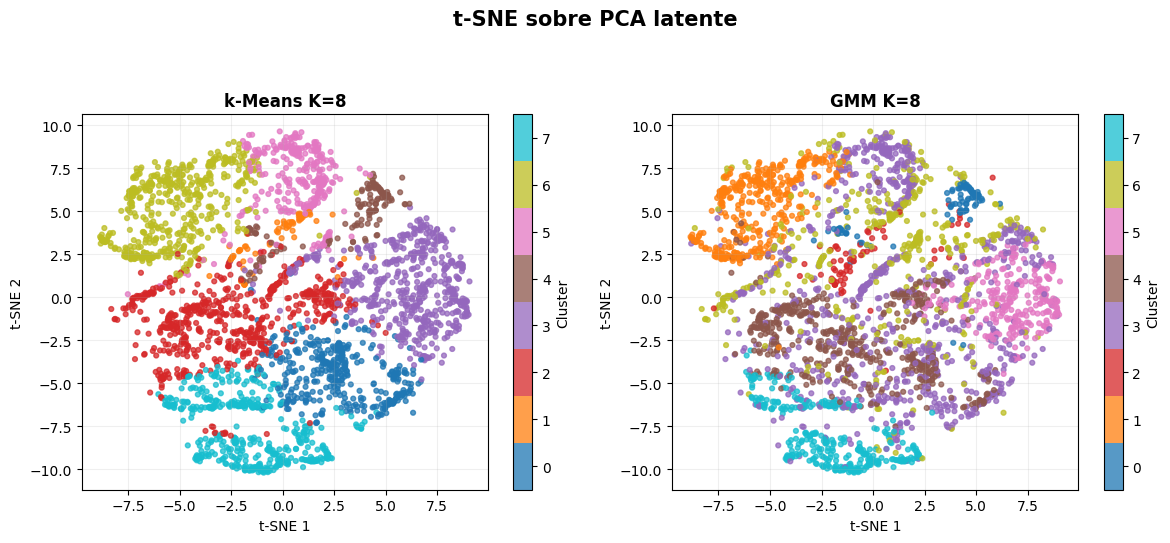

In [ ]:
plot_tsne_cluster_comparison(zeval_pca_tsne, best_labels_kmeans, best_labels_gmm, title_1=f"k-Means K={k_kmeans}", title_2=f"GMM K={k_gmm}", general_title="t-SNE sobre PCA latente")

In [ ]:
# K-Means tables
print("======================= Tablas de k-Means =======================")
kmeans_cluster_size_table = build_cluster_size_table(best_labels_kmeans)
kmeans_cluster_class_table = build_cluster_class_table(best_labels_kmeans, ytr_sample)
kmeans_cluster_purity_table = build_cluster_purity_table(best_labels_kmeans, ytr_sample)

# GMM tables
print("\n======================= Tablas de GMM =======================")
gmm_cluster_size_table = build_cluster_size_table(best_labels_gmm)
gmm_cluster_class_table = build_cluster_class_table(best_labels_gmm, ytr_sample)
gmm_cluster_purity_table = build_cluster_purity_table(best_labels_gmm, ytr_sample)

======================= Tablas de k-Means =======================

------------------ Tamaño de clusters ------------------


cluster,count,percentage
0,381,12.700%
1,68,2.267%
2,601,20.033%
3,542,18.067%
4,138,4.600%
5,309,10.300%
6,514,17.133%
7,447,14.900%



------------------ Composición de clases por cluster ------------------


,0: T-shirt/top,1: Trouser,2: Pullover,3: Dress,4: Coat,5: Sandal,6: Shirt,7: Sneaker,8: Bag,9: Ankle boot
cluster,,,,,,,,,,
0,184,14,13,71,49,0,46,0,3,1
1,2,0,0,0,0,4,1,0,5,56
2,87,28,102,66,52,66,125,0,71,4
3,11,2,180,3,189,0,117,0,39,1
4,2,0,2,0,2,0,3,0,129,0
5,0,0,1,0,0,33,0,21,34,220
6,2,0,0,0,0,197,0,279,18,18
7,12,256,2,160,8,0,8,0,1,0



------------------ Pureza de clusters ------------------


...

cluster,count,percentage
0,94,3.133%
1,404,13.467%
2,72,2.400%
3,853,28.433%
4,494,16.467%
5,290,9.667%
6,451,15.033%
7,342,11.400%



------------------ Composición de clases por cluster ------------------


,0: T-shirt/top,1: Trouser,2: Pullover,3: Dress,4: Coat,5: Sandal,6: Shirt,7: Sneaker,8: Bag,9: Ankle boot
cluster,,,,,,,,,,
0,4,0,0,0,0,0,1,0,89,0
1,0,0,0,0,0,146,1,244,0,13
2,4,2,3,0,1,5,4,0,35,18
3,108,49,90,109,94,49,78,35,77,164
4,150,6,76,69,62,6,115,5,4,1
5,0,0,104,0,126,0,60,0,0,0
6,33,10,27,16,16,94,40,16,95,104
7,1,233,0,106,1,0,1,0,0,0



------------------ Pureza de clusters ------------------


cluster,size,dominant_class,dominant_count,purity
0,94,8: Bag,89,0.947
1,404,7: Sneaker,244,0.604
2,72,8: Bag,35,0.486
3,853,9: Ankle boot,164,0.192
4,494,0: T-shirt/top,150,0.304
5,290,4: Coat,126,0.434
6,451,9: Ankle boot,104,0.231
7,342,1: Trouser,233,0.681


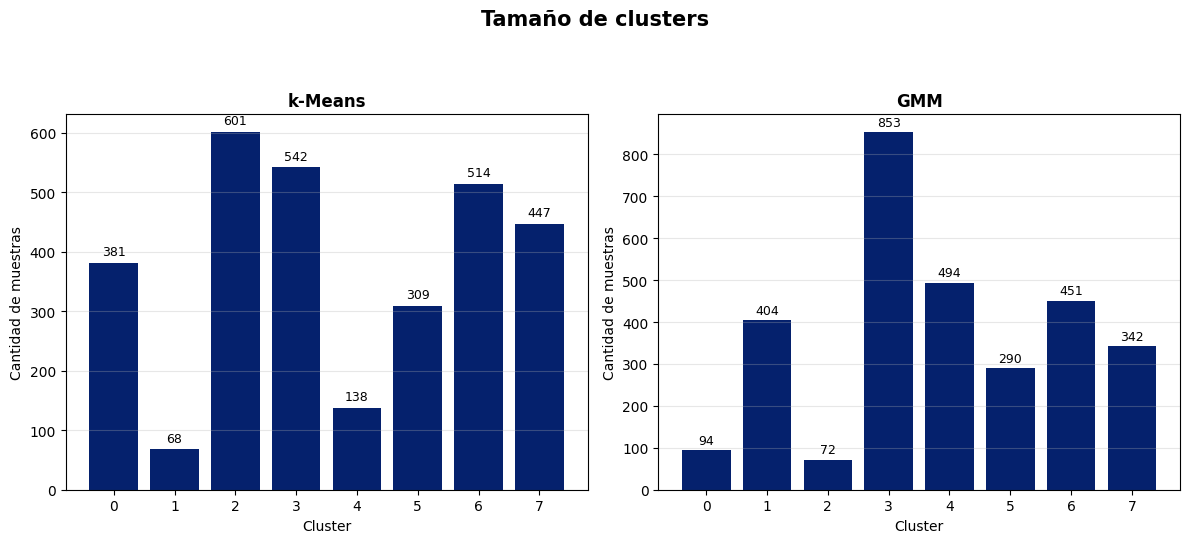

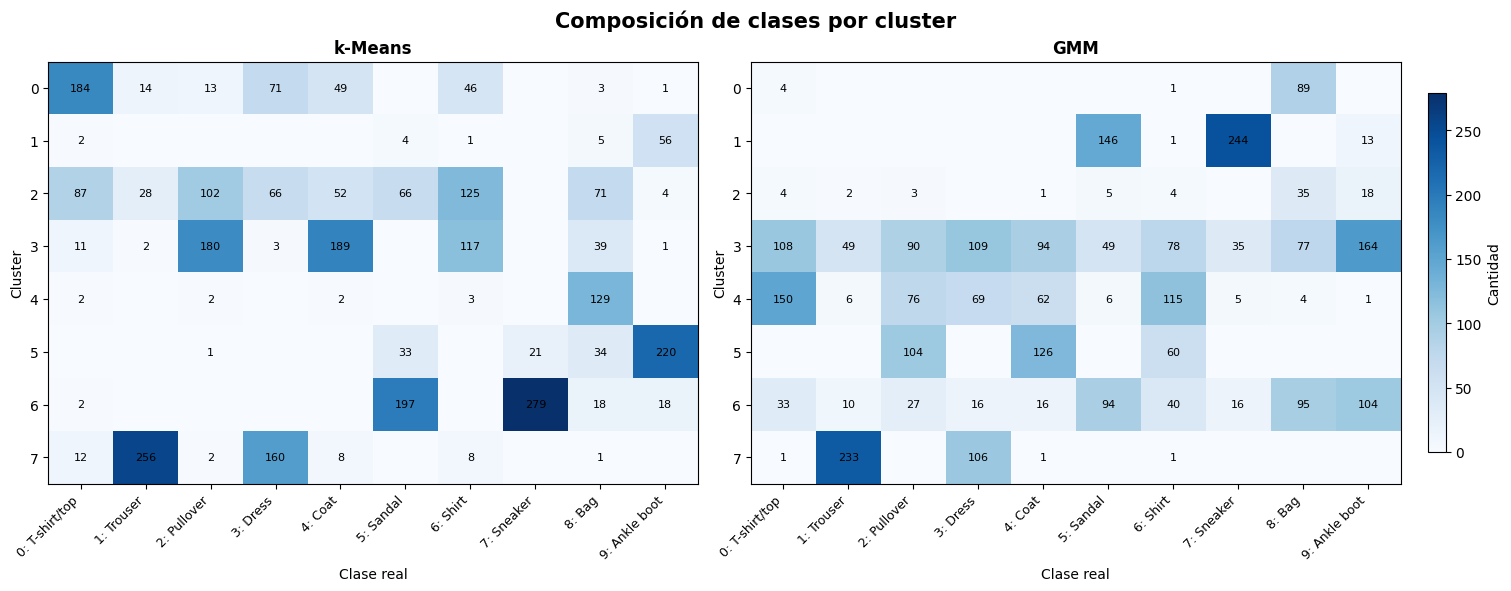

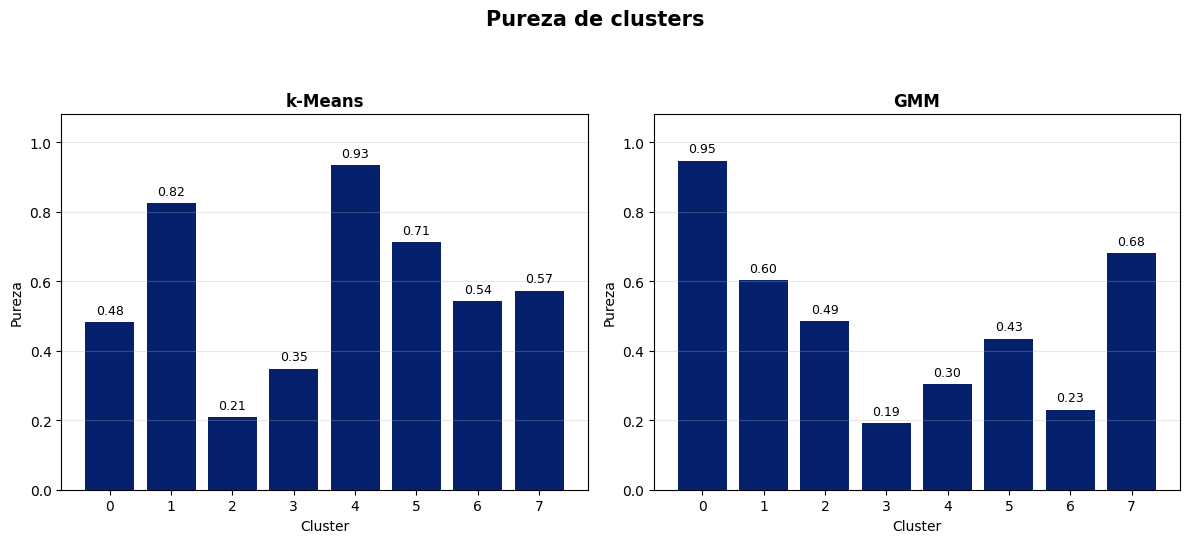

In [ ]:
# Gráficos de comparación
plot_cluster_size_comparison(kmeans_cluster_size_table, gmm_cluster_size_table)
plot_cluster_class_heatmap_comparison(kmeans_cluster_class_table, gmm_cluster_class_table)
plot_cluster_purity_comparison(kmeans_cluster_purity_table, gmm_cluster_purity_table)

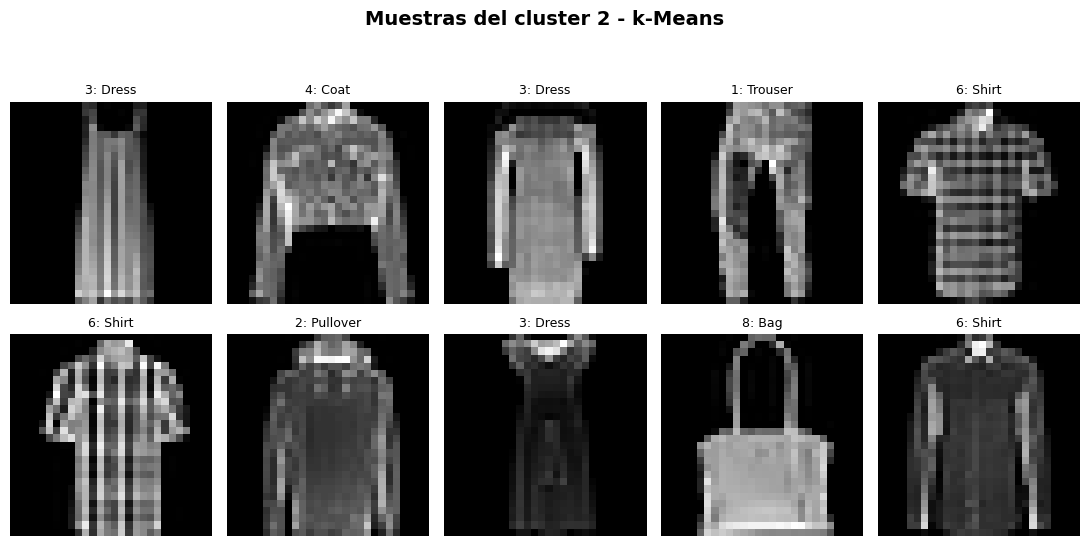

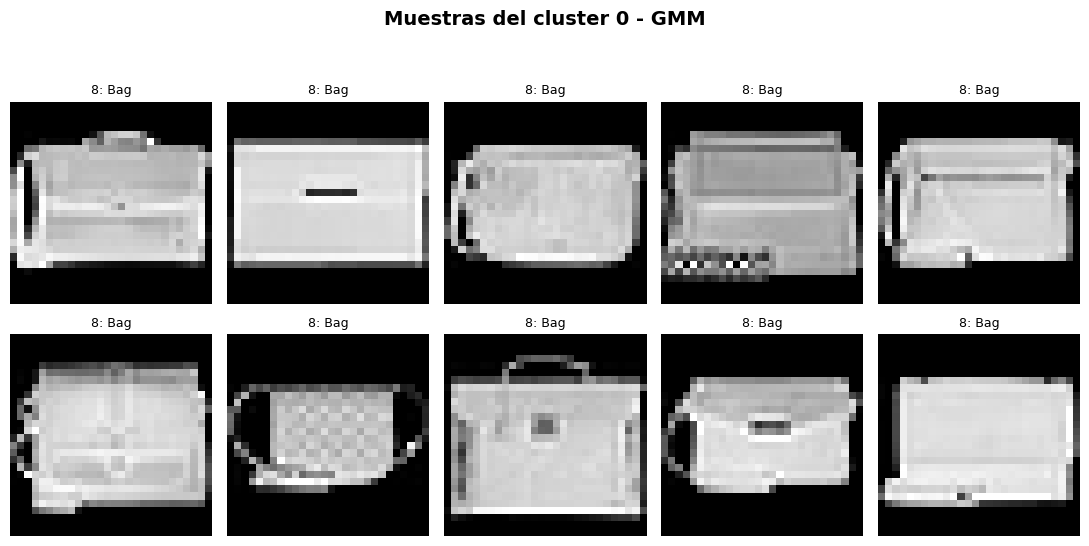

In [ ]:
# Original images corresponding to the stratified sample
xtr_original_sample = xeval.iloc[sample_indices]
ytr_original_sample = yeval.iloc[sample_indices]

# Visual examples within clusters
plot_images_by_cluster(xtr_original_sample, best_labels_kmeans, ytr_original_sample,
                       cluster_id = 2, n_images = 10, title = "Muestras del cluster 2 - k-Means")
plot_images_by_cluster(xtr_original_sample, best_labels_gmm, ytr_original_sample,
                       cluster_id = 0, n_images = 10, title = "Muestras del cluster 0 - GMM")

A partir de los resultados, se puede decir que los clusters tienen una calidad intermedia. No separan perfectamente las clases reales, pero sí capturan cierta estructura visual del dataset.

En cuanto al tamaño, k-Means genera grupos más balanceados que GMM. La mayoría de sus clusters tienen una cantidad razonable de muestras, aunque algunos son más chicos. En cambio, GMM queda más desparejo: algunos clusters concentran muchas observaciones y otros agrupan muy pocas.

Respecto a la homogeneidad, ambos métodos tienen clusters bastante puros, pero también otros muy mezclados. En k-Means, por ejemplo, algunos clusters alcanzan purezas altas, mientras que otros combinan varias clases. En GMM ocurre algo similar: ciertos clusters son muy homogéneos, pero otros mezclan muchas categorías.

La tabla de composición muestra que algunas clases, como zapatillas, botas, bolsos o pantalones, tienden a concentrarse mejor. En cambio, prendas visualmente parecidas, como remeras, camisas, pulóveres y abrigos, aparecen más mezcladas.

La visualización con t-SNE también muestra cierta separación entre grupos, especialmente en k-Means, aunque todavía hay zonas de superposición. En conclusión, los clusters son parcialmente informativos: reflejan algunas similitudes visuales, pero no recuperan de forma perfecta las 10 clases reales de Fashion-MNIST.